### 作者：东哥起飞

### 本篇文章来源于[《100天成为风控专家》](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2ZAoFMNREbOv3DutKsoIi9Vlfky) 策略置换的D类调优(2)：Python实操

In [337]:
import pandas as pd
import numpy as np
import scorecardpy as sc
from sklearn import tree
from sklearn.tree import _tree
from sklearn import metrics
import seaborn as sns
from matplotlib import pyplot as plt
import os, re, sys
%matplotlib inline
## 设置属性防止中文乱码
plt.rcParams['font.sans-serif'] = [u'SimHei']
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings("ignore")

In [338]:
import sklearn as sk
import matplotlib as mpl
print('python:%s'%(sys.version))
print('sklearn:%s'%(sk.__version__))
print('pandas:%s'%(pd.__version__))
print('numpy:%s'%(np.__version__))
print('matplotlib:%s'%(mpl.__version__))
print('seaborn:%s'%(sns.__version__))
print('scorecardpy:%s'%(sc.__version__))

python:3.8.5 (default, Sep  3 2020, 21:29:08) [MSC v.1916 64 bit (AMD64)]
sklearn:1.3.2
pandas:2.0.0
numpy:1.23.5
matplotlib:3.7.1
seaborn:0.12.2
scorecardpy:0.1.9.7


## **0. 样本数据**

In [339]:
df = pd.read_excel('data_v5.xlsx')
df.shape

(50000, 5)

In [340]:
df.head(2)

,sample_id,sample_month,risk_score,card_level,is_dlq_30d
0,1,201802,1,A,0.0
1,2,201804,2,B,0.0


模型迭代前后：

- `card_level`：旧评分卡模型，A-E等级风险逐渐变高
- `risk_score`：新风险模型分，数值越大风险越高

## **1. 分箱分析**

In [341]:
# 筛选通过样本
df_tg = df.loc[df['is_dlq_30d'].isnull()==False].reset_index(drop=True)
print(df_tg.shape)
# 通过样本整体坏账率
ttbadrate = df_tg.is_dlq_30d.mean()
print('通过样本坏客户浓度:{}%'.format(round(ttbadrate*100,2)))

(40407, 5)
通过样本坏客户浓度:7.79%


In [342]:
# 类型修改（因为有空值需转换否则报错）
df_tg['is_dlq_30d'] = df_tg['is_dlq_30d'].astype(int)
# 去除非分析对象
var0 = df_tg.columns.difference(['sample_id','sample_month']).tolist()

def bins_calc(df:pd.DataFrame, col_lst:list):
    """
    计算变量的iv和lift，及分箱下的统计
    """
    # scorecardpy变量分箱
    bins_info = sc.woebin(df[col_lst], y='is_dlq_30d', breaks_list={}, method='tree', stop_limit=0)

    # 计算分箱下的lift值（简易版口径：分箱区间坏账率/整体样本平均坏账率）
    for k,v in bins_info.items():
        v['lift'] = v['badprob']/ttbadrate
        bins_info[k] = v

    # 生成变量的评估指标表
    print('评估指标计算')
    rule_lift = pd.DataFrame(([k,v['total_iv'].max(),v['lift'].max()] for k,v in bins_info.items()), columns=['name','iv','lift']) \
                  .sort_values(by=['iv','lift'],ascending=[False,True])

    display(rule_lift)

    print('变量分箱展示')
    for col in rule_lift['name'].tolist():
        if col == 'is_dlq_30d':
            continue
        else:
            display(bins_info[col].style.bar(subset=['badprob'], color='lightgreen', width=80, height=80, align='left', vmin=0).highlight_max(subset=['lift'], color='red',axis=0))
     
    return bins_info

In [343]:
bins_op = bins_calc(df_tg, var0)

[INFO] creating woe binning ...
评估指标计算


,name,iv,lift
1,risk_score,2.074198,4.849672
0,card_level,0.187129,1.596908


变量分箱展示


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values,lift
0,risk_score,"[-inf,2.0)",10085,0.249585,10053,32,0.003173,-3.279109,0.851451,2.074198,2.0,False,0.040715
1,risk_score,"[2.0,3.0)",6652,0.164625,6558,94,0.014131,-1.774364,0.259350,2.074198,3.0,False,0.181326
2,risk_score,"[3.0,4.0)",7103,0.175786,6828,275,0.038716,-0.741234,0.071109,2.074198,4.0,False,0.496792
3,risk_score,"[4.0,5.0)",6457,0.159799,6041,416,0.064426,-0.204858,0.006153,2.074198,5.0,False,0.826697
4,risk_score,"[5.0,6.0)",6120,0.151459,5296,824,0.134641,0.610245,0.072940,2.074198,6.0,False,1.727666
5,risk_score,"[6.0,inf)",3990,0.098745,2482,1508,0.377945,1.972501,0.813194,2.074198,inf,False,4.849672


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values,lift
0,card_level,A,21941,0.543000,20824,1117,0.050909,-0.454678,0.092844,0.187129,A,False,0.653252
1,card_level,B,7779,0.192516,7077,702,0.090243,0.160110,0.005281,0.187129,B,False,1.157970
2,card_level,C,10687,0.264484,9357,1330,0.124450,0.519836,0.089004,0.187129,C,False,1.596908


## **2. 决策矩阵分析**

In [344]:
df['card_level'].value_counts()

card_level
A    21941
C    10687
B     7779
E     6754
D     2839
Name: count, dtype: int64

In [345]:
# 加工出两个模型的决策结果（1：拒绝；0：通过）
df['risk_score_hit'] = df['risk_score'].map(lambda x:1 if x>=6 else 0)
df['card_level_hit'] = df['card_level'].map(lambda x:1 if x=='D' or x=='E' else 0)

### 2.1. 透视表（新旧模型决策结果透视统计“坏客户的数量”）

In [346]:
bad_sum = df.pivot_table(index='card_level_hit', columns='risk_score_hit', values='is_dlq_30d', aggfunc='sum', margins=True)
bad_sum

risk_score_hit,0,1,All
card_level_hit,,,
0,1641.0,1508.0,3149.0
1,0.0,0.0,NaN
All,1641.0,1508.0,3149.0


### 2.2. 交叉表（新旧模型决策结果交叉统计“总客户的数量”）

In [347]:
all_sum = pd.crosstab(df['card_level_hit'], df['risk_score_hit'], margins=True)
all_sum

risk_score_hit,0,1,All
card_level_hit,,,
0,36417,3990,40407
1,6729,2864,9593
All,43146,6854,50000


### 2.3. 新旧模型决策结果交叉统计badrate坏账率

In [348]:
bad_rate = bad_sum/all_sum
bad_rate

risk_score_hit,0,1,All
card_level_hit,,,
0,0.045061,0.377945,0.077932
1,0.000000,0.000000,NaN
All,0.038034,0.220018,0.062980


由于旧模型拒绝的客户没有贷后表现，所以这里card_level为1时，坏账率为空的。

## **3. 效果测算**

In [297]:
# 筛选出样本中的被拒绝客户，即没有贷后表现的客群
df_jj = df.loc[df['is_dlq_30d'].isnull()==True].reset_index(drop=True)
df_jj.shape

(9593, 7)

### 3.1. 按照risk_score在通过样本上的分箱，对旧模型的拒绝样本，统计数量的分布

In [350]:
bins_jj = (
    pd.cut(df_jj['risk_score'], bins=[0,2,3,4,5,6,10], right=False, include_lowest=True)
    .value_counts()
    .sort_index()
    .to_frame(name='bins_cnt')
    .reset_index()
)

In [351]:
bins_jj

,risk_score,bins_cnt
0,"[0, 2)",866
1,"[2, 3)",868
2,"[3, 4)",1317
3,"[4, 5)",1619
4,"[5, 6)",2059
5,"[6, 10)",2864


In [352]:
# 将以上分布结果与通过样本的分箱拼接
df_jjc = pd.concat([bins_op['risk_score'], bins_jj],axis=1)
df_jjc.style.highlight_between(subset=['badprob','bins_cnt'])

,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values,lift,risk_score,bins_cnt
0,risk_score,"[-inf,2.0)",10085,0.249585,10053,32,0.003173,-3.279109,0.851451,2.074198,2.0,False,0.040715,"[0, 2)",866
1,risk_score,"[2.0,3.0)",6652,0.164625,6558,94,0.014131,-1.774364,0.259350,2.074198,3.0,False,0.181326,"[2, 3)",868
2,risk_score,"[3.0,4.0)",7103,0.175786,6828,275,0.038716,-0.741234,0.071109,2.074198,4.0,False,0.496792,"[3, 4)",1317
3,risk_score,"[4.0,5.0)",6457,0.159799,6041,416,0.064426,-0.204858,0.006153,2.074198,5.0,False,0.826697,"[4, 5)",1619
4,risk_score,"[5.0,6.0)",6120,0.151459,5296,824,0.134641,0.610245,0.072940,2.074198,6.0,False,1.727666,"[5, 6)",2059
5,risk_score,"[6.0,inf)",3990,0.098745,2482,1508,0.377945,1.972501,0.813194,2.074198,inf,False,4.849672,"[6, 10)",2864


### 3.2. 计算拒绝样本的坏客户数量

In [354]:
# 用拒绝样本得到分布数据，乘以通过样本对应的badrate，得到对应分箱下的坏客户数量
df_jjc['jjbad_cnt'] = df_jjc['bins_cnt']*df_jjc['badprob']
df_jjc.style.highlight_between(subset=['jjbad_cnt'])

,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values,lift,risk_score,bins_cnt,jjbad_cnt
0,risk_score,"[-inf,2.0)",10085,0.249585,10053,32,0.003173,-3.279109,0.851451,2.074198,2.0,False,0.040715,"[0, 2)",866,2.747843
1,risk_score,"[2.0,3.0)",6652,0.164625,6558,94,0.014131,-1.774364,0.259350,2.074198,3.0,False,0.181326,"[2, 3)",868,12.265785
2,risk_score,"[3.0,4.0)",7103,0.175786,6828,275,0.038716,-0.741234,0.071109,2.074198,4.0,False,0.496792,"[3, 4)",1317,50.989019
3,risk_score,"[4.0,5.0)",6457,0.159799,6041,416,0.064426,-0.204858,0.006153,2.074198,5.0,False,0.826697,"[4, 5)",1619,104.306024
4,risk_score,"[5.0,6.0)",6120,0.151459,5296,824,0.134641,0.610245,0.072940,2.074198,6.0,False,1.727666,"[5, 6)",2059,277.224837
5,risk_score,"[6.0,inf)",3990,0.098745,2482,1508,0.377945,1.972501,0.813194,2.074198,inf,False,4.849672,"[6, 10)",2864,1082.434085


### 3.3. 逾期率对比

In [355]:
# 对置入样本按照risk_score的cutoff计算出badrate坏账率
df_jj_cutoff = df_jjc.loc[df_jjc.index<5]
# 覆盖前面旧模型无贷后表现的部分（新模型置入部分）
bad_sum.iat[1,0] = df_jj_cutoff['jjbad_cnt'].sum()
display(bad_sum)
bad_rate = bad_sum/all_sum
bad_rate.style.highlight_between(left=0.03,right=0.04).highlight_between(left=0.07,right=0.08)

risk_score_hit,0,1,All
card_level_hit,,,
0,1641.000000,1508.0,3149.0
1,447.533508,0.0,NaN
All,1641.000000,1508.0,3149.0


risk_score_hit,0,1,All
card_level_hit,,,
0,0.045061,0.377945,0.077932
1,0.066508,0.000000,nan
All,0.038034,0.220018,0.062980


### 3.4. 通过率对比

In [356]:
pass_rate = all_sum/df.shape[0]
pass_rate.style.highlight_between(left=0.8,right=0.9)

risk_score_hit,0,1,All
card_level_hit,,,
0,0.728340,0.079800,0.808140
1,0.134580,0.057280,0.191860
All,0.862920,0.137080,1.000000


可以看到，card_level的通过率为80.8%，而risk_score新模型的通过率为86.29%。

**综上所述，经过置入置出分析以后，新模型risk_score的通过率高于旧模型card_level，同时risk_score置入的样本坏账率仅为3.8%，而置出的样本坏账率为37.79%。因此，从业务的角度来看，新模型的效果是远远超过旧模型的，建议迭代上线。**

## **番外**

如果对pandas不熟悉想要进阶的朋友可以了解下东哥的这个原创笔记，已经完全体，后续随着版本迭代会持续更新。

[《pandas进阶宝典》](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2YD5u0x8FzrAIyM8soEuxnTkP9r)永久访问权限，500页图文笔记，近30万字，配套完整代码支持下载。

5大核心图文，具体包括：
- 《pandas快速入门》
- 《pandas进阶宝典》
- 《pandas实战项目》
- 《pandas进阶题库》
- 《Numpy速查手册》
- 《正则表达式手册》

感兴趣可以扫码了解，或者加我微信可以有折扣，加V：`Petery_1966`

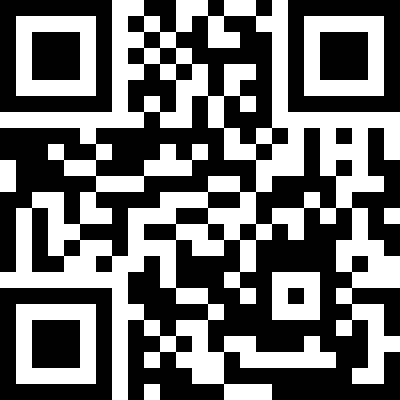